<a href="https://colab.research.google.com/github/seun829/DataScience/blob/main/Unit6/SeunLee_U6proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting the Rating of a Movie Based on Multiple Factors

In [4]:
!pip install bambi

In [5]:
import pandas as pd
import bambi as bmb
import arviz as az
import graphviz as gv
import seaborn as sns
import matplotlib.pyplot as plt

In this project, I will try to predict the rating given to a movie from a vote average based on multiple factors. I chose this topic because I am a movie enjoyer and would like to find out what different variables lead to a good audience rating. I feel that there will be quite a few nuances in what leads to a good rating, and expect to find very useful information.

Going into this, I am expecting the most correlation with popularity score (which is out of 100), but am open to the possibility of strong correlations with other variables.

# Data Wrangling

In [6]:
url = "https://raw.githubusercontent.com/seun829/DataScience/refs/heads/main/Movies_dataset.csv"
rating_data = pd.read_csv(url)

release_year_str = rating_data["release_date"].str[:4]

release_year_numeric = pd.to_numeric(release_year_str, errors='coerce')

rating_data["release_date"] = release_year_numeric

rating_data = rating_data.drop(columns=['id'])
rating_data

,original_title,original_language,genre,overview,popularity,vote_count,vote_average,release_date
0,The Shawshank Redemption,en,"Drama, Crime",Imprisoned in the 1940s for the double murder ...,36.1467,29384,8.714,1994.0
1,The Godfather,en,"Drama, Crime","Spanning the years 1945 to 1955, a chronicle o...",37.3341,22174,8.686,1972.0
2,The Godfather Part II,en,"Drama, Crime",In the continuing saga of the Corleone crime f...,14.6729,13404,8.571,1974.0
3,Schindler's List,en,"Drama, History, War",The true story of how businessman Oskar Schind...,13.6783,16923,8.566,1993.0
4,12 Angry Men,en,Drama,The defense and the prosecution have rested an...,10.6929,9589,8.548,1957.0
...,...,...,...,...,...,...,...,...
9995,Tammy,en,Comedy,"For Tammy, a burger-joint employee, a bad day ...",2.7543,1257,5.336,2014.0
9996,A Good Day to Die Hard,en,"Action, Thriller","Iconoclastic, take-no-prisoners cop John McCla...",4.2306,6606,5.335,2013.0
9997,Amityville: The Awakening,en,Horror,"Belle, her little sister, and her comatose twi...",5.5595,1068,5.334,2017.0
9998,Vanishing on 7th Street,en,"Mystery, Horror, Thriller",A mysterious global blackout yields countless ...,4.5139,601,5.334,2010.0


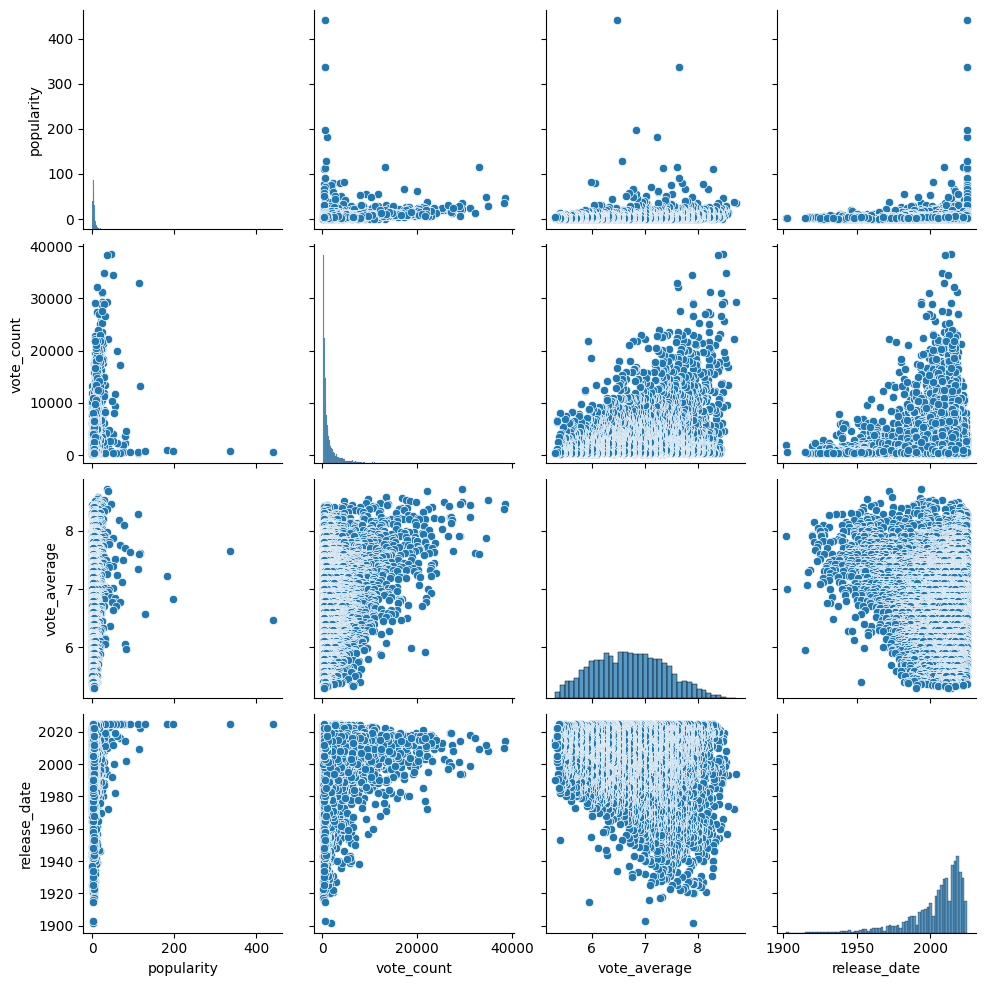

In [7]:
sns.pairplot(rating_data)

Off the bat, there are minimal correlations, lots of clusters though, will impact how I choose what to compare.

# Causal Diagram

The variables given in the dataset that I could use are vote_count, release_date, and popularity score to compare with audience rating.

By popularity score, this means "A metric indicating the popularity of the movie, computed based on user interactions and ratings." This was taken from the dataset description. Although the metric's exact formula was not indicated, it is certainly based on factors other than the rating, as that would make the collumn redundant.

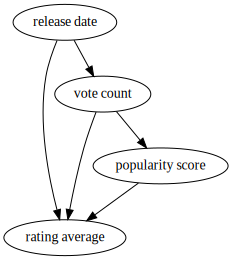

In [8]:
rating_graph = gv.Digraph(comment='rating dag')

rating_graph.node("R", "rating average")
rating_graph.node("V", "vote count")
rating_graph.node("D", "release date")
rating_graph.node("P", "popularity score")

rating_graph.edges(["PR", "DR", "VR", "DV", "VP"])

rating_graph

# Reference Model

In [9]:
ref_model = bmb.Model("vote_average ~ release_date + vote_count + popularity", data=rating_data, dropna=True)
idata_rating_bmb = ref_model.fit(idata_kwargs={'log_likelihood' : True}, progressbar=False)

<Axes: xlabel='vote_average'>

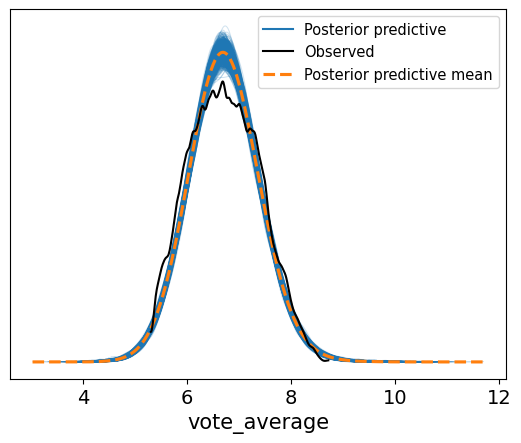

In [10]:
ref_model.predict(idata_rating_bmb, kind="response")
az.plot_ppc(idata_rating_bmb)

# Other Models

For these models, I will aim to try out different combinations based on the causal diagram and play around to see the accuracy differences.

In [11]:
model = bmb.Model("vote_average ~ release_date + vote_count + vote_count:popularity", data=rating_data, dropna=True)
idata_rating_bmb1 = model.fit(idata_kwargs={'log_likelihood' : True}, progressbar=False)

<Axes: xlabel='vote_average'>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


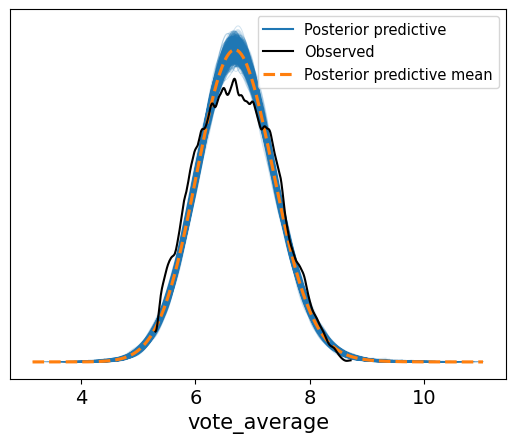

In [12]:
model.predict(idata_rating_bmb1, kind="response")
az.plot_ppc(idata_rating_bmb1)

In [13]:
model2 = bmb.Model("vote_average ~ vote_count + popularity + vote_count:release_date", data=rating_data, dropna=True)
idata_rating_bmb2 = model2.fit(idata_kwargs={'log_likelihood' : True}, target_accept=0.95, progressbar=False)

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<Axes: xlabel='vote_average'>

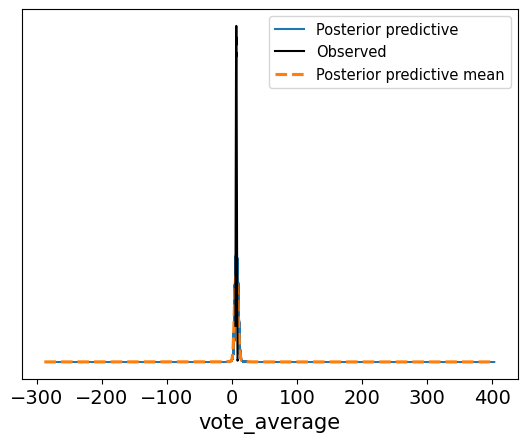

In [14]:
model2.predict(idata_rating_bmb2, kind="response")
az.plot_ppc(idata_rating_bmb2)

At first, this model performed so much worse than I expected. Since there were 1000 divergences after tuning due to the interaction term, the posterior was much less accurate, so I tried to set the target accept to a high percentage to help mitigate that.

In [15]:
model3 = bmb.Model("vote_average ~  vote_count:release_date + popularity:release_date", data=rating_data, dropna=True)
idata_rating_bmb3 = model3.fit(idata_kwargs={'log_likelihood' : True}, target_accept=0.95, draws=2000, progressbar=False)

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<Axes: xlabel='vote_average'>

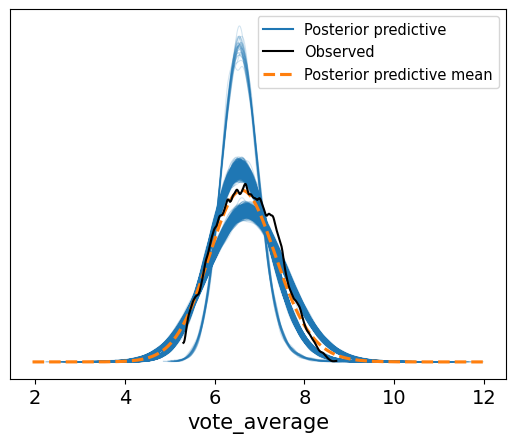

In [16]:
model3.predict(idata_rating_bmb3, kind="response")
az.plot_ppc(idata_rating_bmb3)

This model took so much time to run, due to a complex posterior with multiple interactions. Looking at the posterior predicative, the predictions varied but overall did not perform poorly.

In [19]:
model4 = bmb.Model("vote_average ~ release_date + vote_count", data=rating_data, dropna=True)
idata_rating_bmb4 = model4.fit(idata_kwargs={'log_likelihood' : True}, progressbar=False)

<Axes: xlabel='vote_average'>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


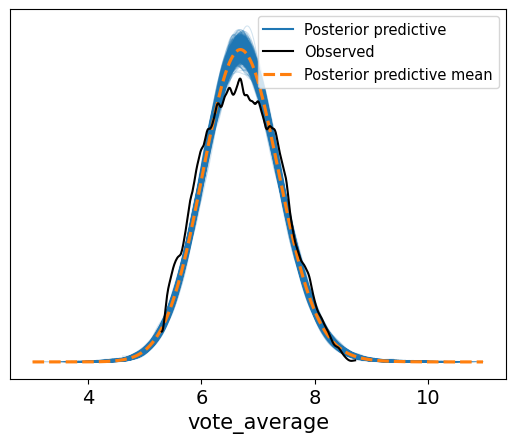

In [20]:
model4.predict(idata_rating_bmb4, kind="response")
az.plot_ppc(idata_rating_bmb4)

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1057: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should c

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
vote_average ~ release_date + vote_count + popularity,0,-9429.750867,9.563005,0.000000,0.971412,63.128551,0.000000,False,log
vote_average ~ release_date + vote_count,1,-9452.190201,3.373972,22.439334,0.029037,62.290213,12.786815,False,log
vote_average ~ release_date + vote_count + (1 | popularity),2,-9453.262841,104.128199,23.511974,0.000431,62.269084,12.792856,True,log
vote_average ~ release_date + vote_count + vote_count:popularity,3,-9453.791083,5.127580,24.040216,0.000431,62.328114,12.662150,True,log
vote_average ~ vote_count:release_date + popularity:release_date,4,-10373.707507,284.650954,943.956640,0.000387,50.501889,30.964142,True,log
vote_average ~ vote_count + popularity + vote_count:release_date,5,-165575.114406,111233.010320,156145.363539,0.000000,54080.064873,54070.482284,True,log


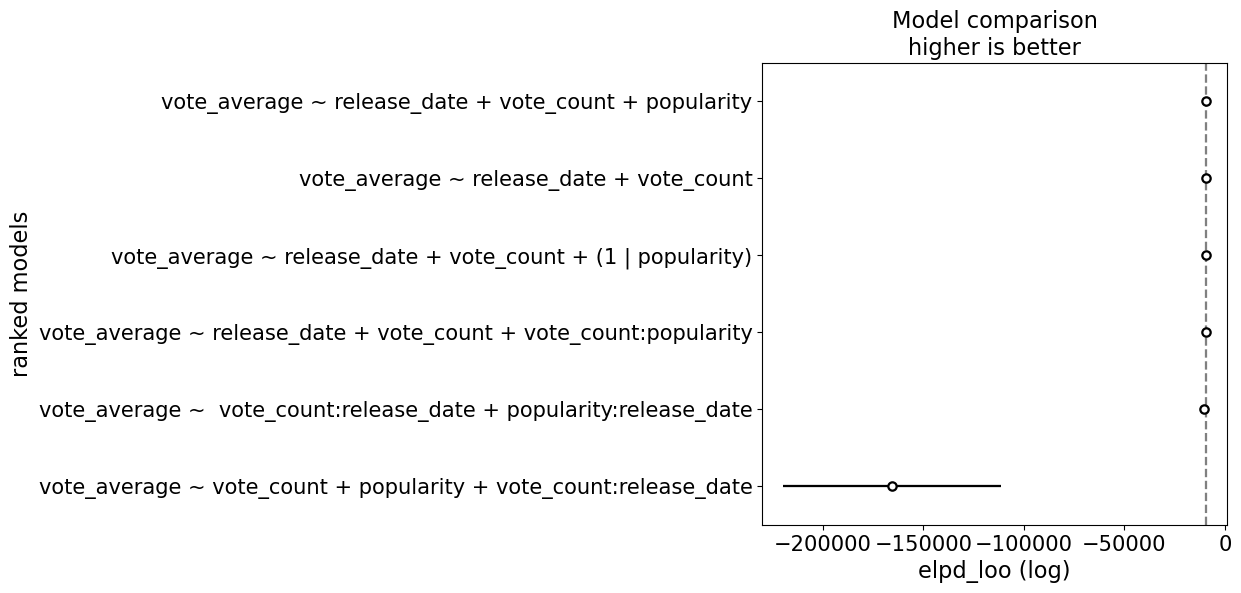

In [21]:
model_dict = {
    "vote_average ~ release_date + vote_count + popularity" : idata_rating_bmb,
    "vote_average ~ release_date + vote_count + vote_count:popularity": idata_rating_bmb1,
    "vote_average ~ vote_count + popularity + vote_count:release_date": idata_rating_bmb2,
    "vote_average ~  vote_count:release_date + popularity:release_date": idata_rating_bmb3,
    "vote_average ~ release_date + vote_count" : idata_rating_bmb4
}

# Compare the models
compare_df = az.compare(model_dict)

# Plot the comparison
az.plot_compare(compare_df)

compare_df

Since the one outlier (model 2) messed up the scale, I will do an elpd_loo without model_2.

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1057: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should c

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
vote_average ~ release_date + vote_count + popularity,0,-9429.750867,9.563005,0.000000,9.536014e-01,63.128551,0.000000,False,log
vote_average ~ release_date + vote_count,1,-9453.262841,104.128199,23.511974,4.639900e-02,62.269084,12.792856,True,log
vote_average ~ release_date + vote_count + vote_count:popularity,2,-9453.791083,5.127580,24.040216,1.895717e-10,62.328114,12.662150,True,log
vote_average ~ vote_count:release_date + popularity:release_date,3,-10373.707507,284.650954,943.956640,0.000000e+00,50.501889,30.964142,True,log


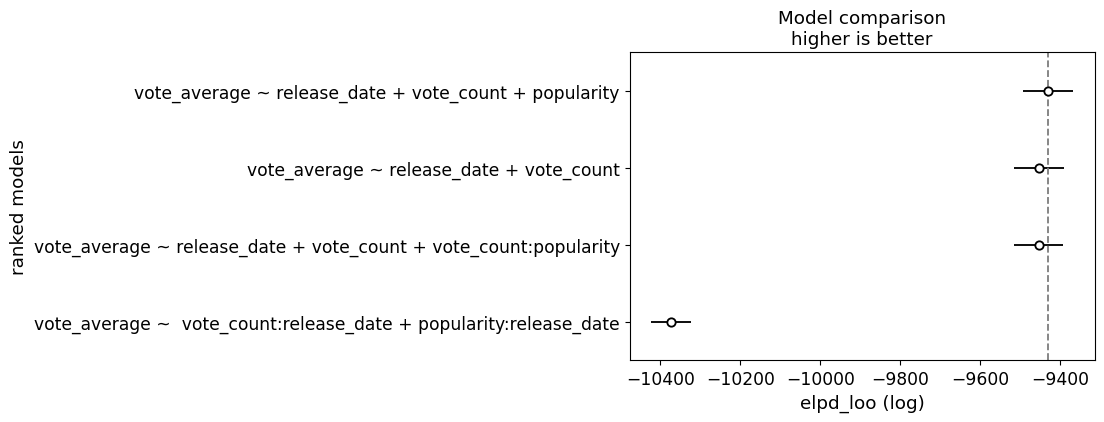

In [23]:
model_dict = {
    "vote_average ~ release_date + vote_count + popularity" : idata_rating_bmb,
    "vote_average ~ release_date + vote_count + vote_count:popularity": idata_rating_bmb1,
    "vote_average ~  vote_count:release_date + popularity:release_date": idata_rating_bmb3,
    "vote_average ~ release_date + vote_count" : idata_rating_bmb4
}

# Compare the models
compare_df = az.compare(model_dict)

# Plot the comparison
az.plot_compare(compare_df)

compare_df

# Conclusion

Surprisingly, my reference model performed the best out of my models. I expected this to not be the case, as my variables are so interconnected that you would expect a better performance with relations to other variables or hierarchies. This suggests that a simple additive combination of all three factors is the most effective in explaining the rating of a movie. The lack of interactions led it to not have complexity or convergence issues leading to worse performance.

My takeaway from this is that complexity is not always the best path and going into simple models that account for all variables can be more accurate than complex models that may pick up on noise and go too deep into interactions.

In the future, I hope to do this but with more features if possible to truly see how the reference model's performance compares to the others when there are even more variables to account for. Additionally, I could take something like genre and represent that numerically so that I can see how that impacts the model performance.